In [1]:
#Import relevant packages
import worldtube_postprocess as wpp
import matplotlib.pyplot as plt
import numpy as np
from spectre.SphericalHarmonics import SpherepackIterator
import h5py

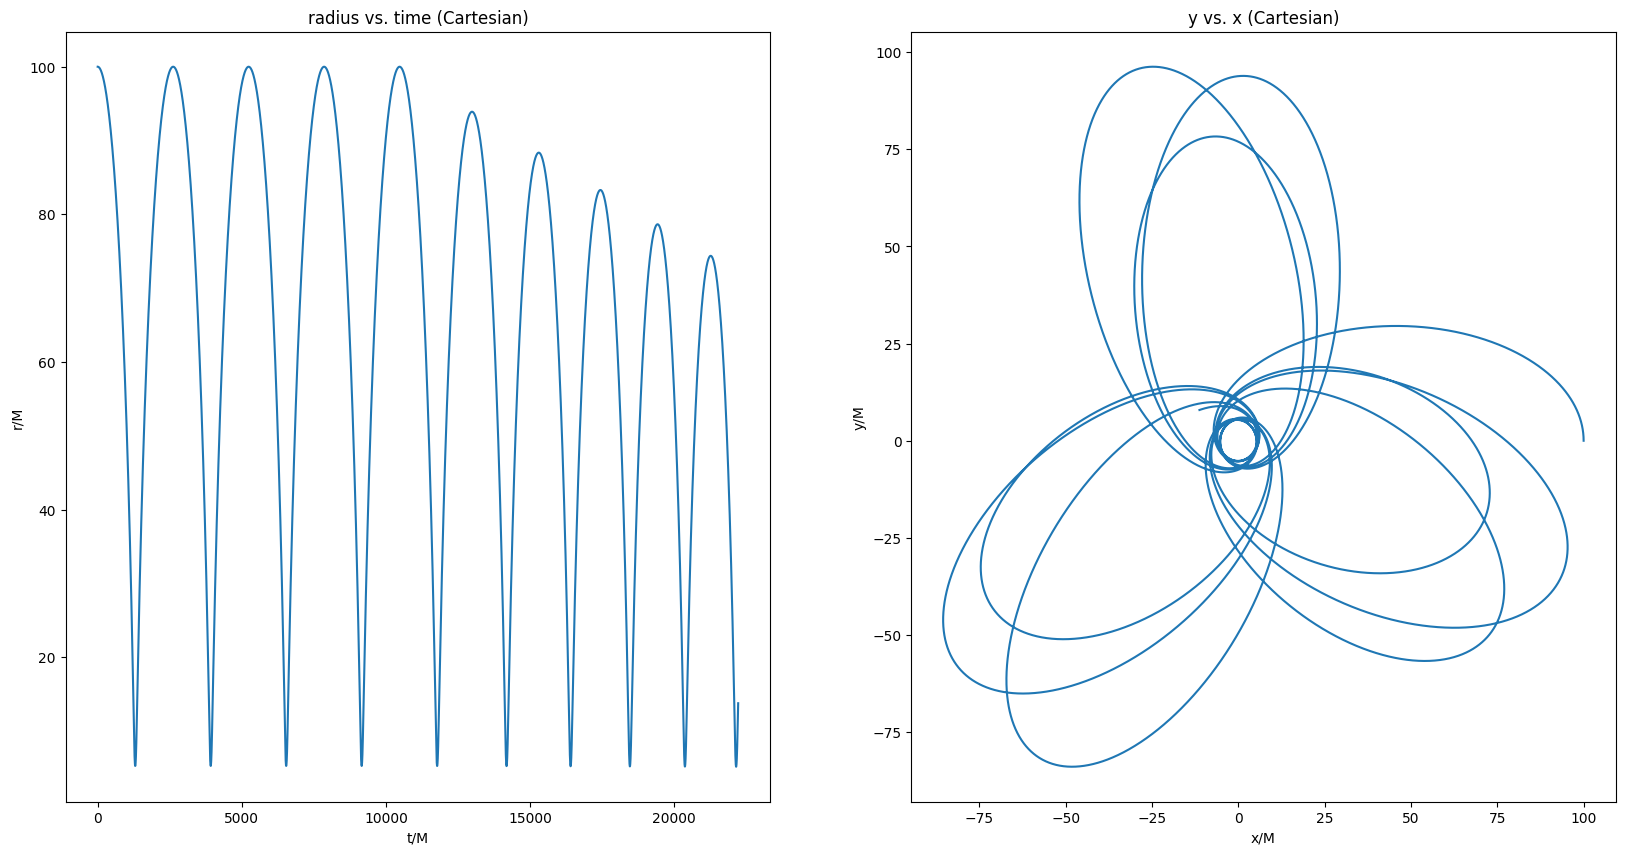

In [7]:
#Extract out the simulation data for trajectory plot
sim_data=wpp.extract_sim_data('.')
traj_pos=sim_data['position']
time=sim_data['times']
# print(sim_data)
# print(traj_pos)

#Plot the trajectory
fig,ax=plt.subplots(1,2,figsize=(20,10))
# ax[1]=plt.subplot(122,projection='polar')
labellist=[['t/M','r/M','radius vs. time (Cartesian)'],['x/M','y/M','y vs. x (Cartesian)']]
for n,row in enumerate(ax):
    # print(n)
    row.set_xlabel(labellist[n][0])
    row.set_ylabel(labellist[n][1])
    row.set_title(labellist[n][2])
ax[1].plot(traj_pos[:,0],traj_pos[:,1])
ax[0].plot(time,np.sqrt(traj_pos[:,0]**2+traj_pos[:,1]**2))
plt.show()

In [ ]:
#Extract out the simulation data for spherical harmonic modes
time_sph,sphere_pack,radii=wpp.extract_sphere_data('.')

#Extract out the l_max value for the simulation 
# Get lmax from datafile
with h5py.File(f"Reductions.h5", "r") as h5file:
    dat_file = h5file.get("/Spheres_Ylm.dat")
    legend = list(dat_file.attrs["Legend"])
    lmax = int(dat_file[0, legend.index("Lmax")])
    print("lmax : ", lmax)

print(radii)
print(sphere_pack.shape,time_sph.shape)

#Construct own spherepack->ylm converter function
#Extracting alm and blm
iter=SpherepackIterator(lmax,lmax)
iter.set(1,1)
pos_m=sphere_pack[:,iter()][0]
iter.set(1,-1)
neg_m=sphere_pack[:,iter()][0]
print([neg_m[0],pos_m[0]],[neg_m[-1],pos_m[-1]])

lmax :  10
[800.0]
(1, 26349, 242) (26349,)
[np.float64(7.049698089670418e-05), np.float64(7.050021632098079e-05)] [np.float64(-4.000034370635136e-14), np.float64(4.3718827926927605e-14)]


The (l,m) modes are: [(0, 0), (1, -1), (1, 0), (1, 1), (2, -2), (2, -1), (2, 0), (2, 1), (2, 2)]


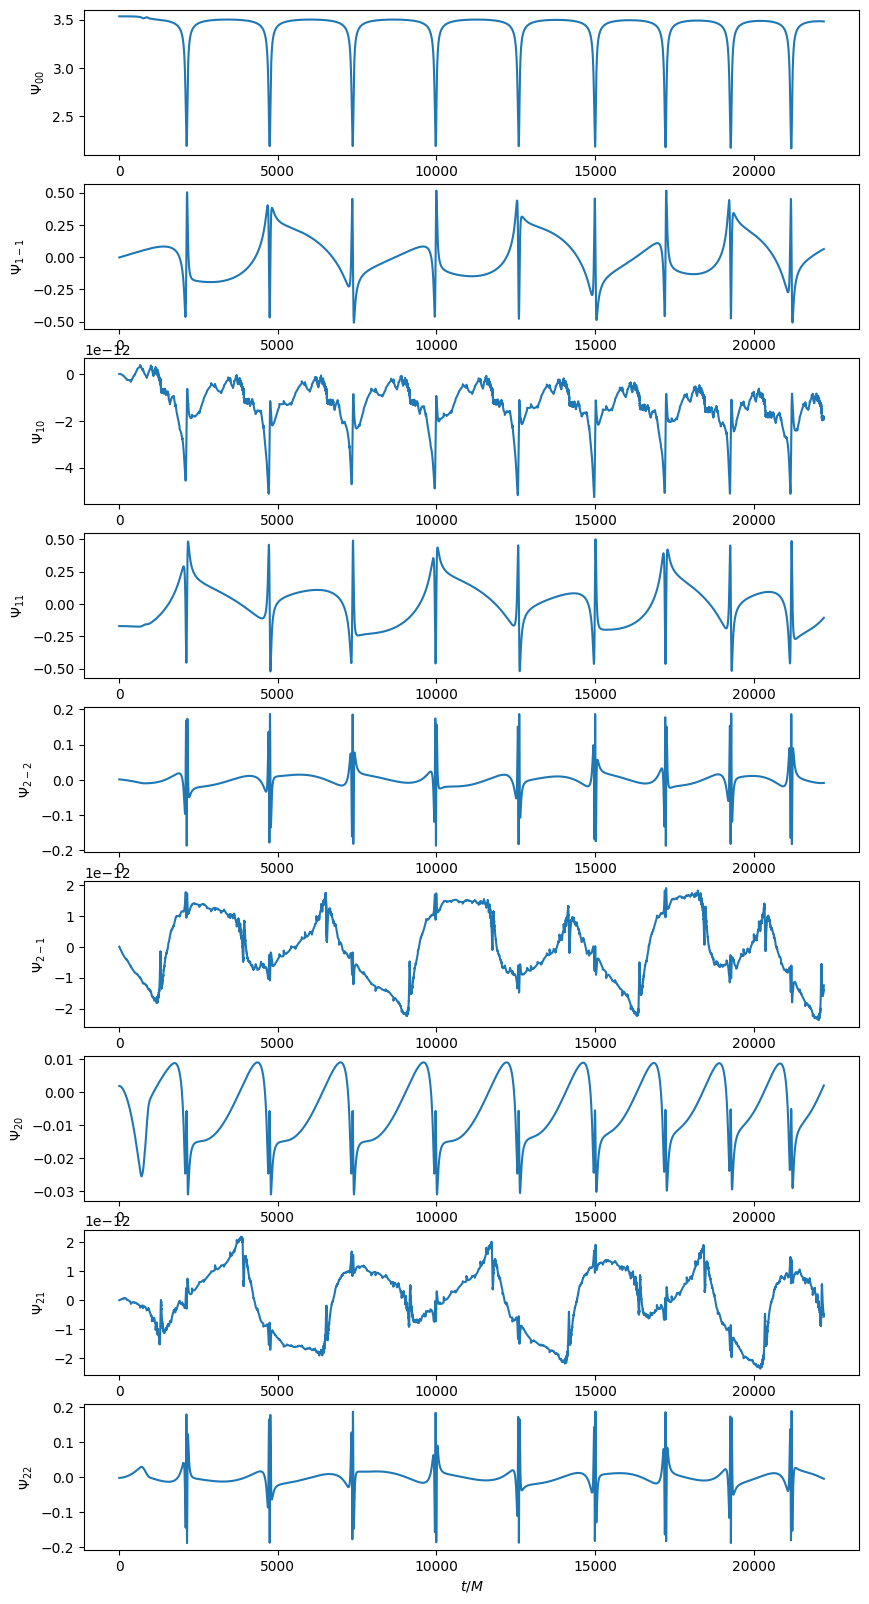

In [15]:
#Plot the spherical harmonic modes
#Generate the modes to plot
lmodes = range(3)
lm_modes = [(l_temp, m) for l_temp in lmodes for m in range(-l_temp,l_temp+1)]
print('The (l,m) modes are:',lm_modes)
#Extract out the spherical harmonic modes
fig,ax=plt.subplots(len(lm_modes),1,figsize=(10,20))
for n,(l,m) in enumerate(lm_modes):
    # label = "(" + str(l) + "," + str(m)+")"
    # index = legend.index("coef" + label)
    ax[n].plot(
        time_sph,
        50*radii[0]*wpp.ylm(data=sphere_pack[0], l=l, m=m, l_max=lmax),) #label=(f"$ a^{{{label}}} $" if m >= 0 else f"$ b^{{{label}}}$"),)
        #The spherical harmonics shown in the letter is divided by sqrt(epsilon*mu) (eps=0.02,mu=0.02) which explains the need for a factor of 50 to get the right scaling.
    ax[n].set_ylabel(rf'$\Psi_{{{l}{m}}}$')
    # ax[n].legend(loc='upper right')
ax[-1].set_xlabel(r'$t/M$')
fig.tight_layout
plt.show()